<a href="https://colab.research.google.com/github/liricsha7/Impact-of-Social-Media-Marketing-on-Consumer-Purchase-Behavior-in-E-Commerce/blob/main/final_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_Final.xlsx to Dataset_Final (2).xlsx


In [ ]:
df = pd.read_excel('Dataset_Final.xlsx')

In [ ]:
# ===================================================================
# COMPREHENSIVE DATA PREPROCESSING & CLEANING
# ===================================================================
print("="*70)
print("COMPREHENSIVE DATA PREPROCESSING & CLEANING")
print("="*70)

# STEP 1: CLEAN COLUMN NAMES
print("\n" + "="*70)
print("STEP 1: Cleaning Column Names")
print("="*70)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
print("\nCleaned Column Names:")
print(df.columns.tolist())
print(f"Dataset Shape: {df.shape}")

# STEP 2: DATA TYPES OVERVIEW
print("\n" + "="*70)
print("STEP 2: Data Types Overview")
print("="*70)
print("\nColumn Data Types:")
print(df.dtypes)
print(f"\nNumerical Columns: {df.select_dtypes(include=['int64', 'float64']).columns.tolist()}")
print(f"Categorical Columns: {df.select_dtypes(include=['object']).columns.tolist()}")

# STEP 3: MISSING VALUES ANALYSIS
print("\n" + "="*70)
print("STEP 3: Missing Values Analysis")
print("="*70)
missing_values = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])
if len(missing_values[missing_values > 0]) == 0:
    print("\n✓ No missing values detected!")
else:
    print("\nHandling missing values...")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"  - {col}: Filled with median")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"  - {col}: Filled with mode")

print(f"\nDataset Shape after handling missing values: {df.shape}")

COMPREHENSIVE DATA PREPROCESSING & CLEANING

STEP 1: Cleaning Column Names

Cleaned Column Names:
['age', 'gender', 'social_media_platforms_do_you_use_the_most', 'daily_time_spend_on_social_media', 'platform_that_mostly_see_online_shopping_ads', 'companys_ads_do_you_often_noticed', 'type_of_product_ads_are_you_getting_often', 'often_see_product_ads', 'check_product_ads', 'click_on_those_ads', 'fashion__accessories', 'health_beauty_and_personal_care', 'home_furnishings_and_lifestyle', 'electronics_media_and_gaming', 'food_beverages_and_grocery', 'specific_or_niche_markets', 'influencer_videos_often_influence_my_purchases', 'mostly_see_influencer_videos', 'searched_for_products_after_watching_influencer_videos', 'social_media_shows_ads_based_on_my_interests', 'preferred_platform_to_buy_a_product', 'check_product_reviews_before_buying', 'purchased_directly_through_an_ad_link', 'purchase_product_through_promoting_video', 'social_media_influence_your_decision', 'suggestions', 'platform', 'i

In [ ]:
# ============================================================================
# COMPREHENSIVE ANALYSIS OF ALL SURVEY QUESTION COLUMNS
# ============================================================================

import pandas as pd
import numpy as np

# Define all question columns (excluding Name, Age, Gender, and category checkboxes)
question_columns = [
    'social_media_platforms_do_you_use_the_most',
    'daily_time_spend_on_social_media',
    'platform_that_mostly_see_online_shopping_ads',
    'companys_ads_do_you_often_noticed',
    'type_of_product_ads_are_you_getting_often',
    'often_see_product_ads',
    'check_product_ads',
    'click_on_those_ads',
    'influencer_videos_often_influence_my_purchases',
    'mostly_see_influencer_videos',
    'searched_for_products_after_watching_influencer_videos',
    'social_media_shows_ads_based_on_my_interests',
    'preferred_platform_to_buy_a_product',
    'check_product_reviews_before_buying',
    'purchased_directly_through_an_ad_link',
    'purchase_product_through_promoting_video',
    'social_media_influence_your_decision',
    'suggestions'
]

print("="*100)
print("COMPREHENSIVE SURVEY ANALYSIS - ALL QUESTIONS")
print("="*100)
print(f"\nTotal Responses in Dataset: {len(df):,}")
print(f"Total Questions to Analyze: {len(question_columns)}")
print("\n" + "="*100)

# Analyze each question systematically
for idx, col in enumerate(question_columns, 1):
    print(f"\n\n{'='*100}")
    print(f"QUESTION {idx}")
    print("="*100)
    print(f"{col}")
    print("="*100)

    # Calculate statistics
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    # Display frequency distribution
    print(f"\n📊 ANSWER FREQUENCY DISTRIBUTION:")
    print("-" * 100)

    n_unique = len(counts)
    display_count = min(10, n_unique)  # Show top 10 or all if less

    for i, (value, count) in enumerate(counts.head(display_count).items(), 1):
        pct = percentages[value]
        # Create visual bar
        bar_length = int(pct / 2)
        bar = '█' * min(bar_length, 50)
        value_str = str(value)[:60]  # Limit value length for display
        print(f"{i:2}. {value_str:<60} | Count: {count:>6,} ({pct:>6.2f}%) {bar}")

    if n_unique > display_count:
        remaining = n_unique - display_count
        remaining_count = counts.iloc[display_count:].sum()
        remaining_pct = (remaining_count / counts.sum()) * 100
        print(f"\n    ... and {remaining} more unique values (Total: {remaining_count:,} responses, {remaining_pct:.2f}%) Jard)")

    # Basic statistics
    print(f"\n📈 STATISTICS:")
    print("-" * 100)
    print(f"Total Responses: {counts.sum():,}")
    print(f"Unique Values: {n_unique:,}")
    most_common_val = str(counts.index[0])[:50]
    print(f"Most Common Answer: '{most_common_val}' ({counts.iloc[0]:,} responses, {percentages.iloc[0]:.2f}%")
    if n_unique > 1:
        print(f"Least Common (displayed): '{str(counts.index[-1])[:50]}' ({counts.iloc[-1]:,} responses, {percentages.iloc[-1]:.2f}%")

    # Special handling for satisfaction/rating columns
    if col == 'social_media_influence_your_decision':
        print(f"\n⭐ RATING DISTRIBUTION (Mapped to 1-5 scale):")
        print("-" * 100)
        mapping = {
            'not at all': 1, 'Slightly': 2, 'slightly': 2,
            'Moderately': 3, 'moderately': 3, 'neutral': 3,
            'Very Strongly': 4, 'very strongly': 4, 'extremely': 5
        }
        mapped = df[col].map(mapping).dropna()
        if len(mapped) > 0:
            rating_counts = mapped.value_counts().sort_index()
            for rating, count in rating_counts.items():
                pct = (count / len(mapped)) * 100
                stars = '⭐' * int(rating)
                print(f"  {stars} ({rating:.0f}): {count:,} ({pct:.2f}%")
            print(f"\n  Average Rating: {mapped.mean():.2f} / 5.00")
            print(f"  Median Rating: {mapped.median():.2f}")

    if col == 'influencer_videos_often_influence_my_purchases':
        print(f"\n⭐ INFLUENCE LEVEL DISTRIBUTION (Mapped to 1-5 scale):")
        print("-" * 100)
        mapping = {
            'Never': 1, 'Not Really': 2, 'Not really': 2,
            'Sometimes': 3, 'Yes, sometimes': 3, 'Yes, a lot': 4, 'Always': 5
        }
        mapped = df[col].map(mapping).dropna()
        if len(mapped) > 0:
            rating_counts = mapped.value_counts().sort_index()
            for rating, count in rating_counts.items():
                pct = (count / len(mapped)) * 100
                stars = '⭐' * int(rating)
                print(f"  {stars} ({rating:.0f}): {count:,} ({pct:.2f}%")
            print(f"\n  Average Influence Level: {mapped.mean():.2f} / 5.00")
            print(f"  Median Influence Level: {mapped.median():.2f}")

    print(f"\n{'='*100}")

print("\n\n" + "="*100)
print("✅ ANALYSIS COMPLETE - ALL SURVEY QUESTIONS DISPLAYED ABOVE")
print("="*100)
print(f"\nSummary:")
print(f"  - Analyzed {len(question_columns)} survey questions")
print(f"  - Dataset contains {len(df):,} total responses")
print(f"  - Each question shows: answer counts, percentages, and top values")
print(f"  - Rating questions include numerical mappings and averages")
print("="*100)

COMPREHENSIVE SURVEY ANALYSIS - ALL QUESTIONS

Total Responses in Dataset: 11,643
Total Questions to Analyze: 18



QUESTION 1
social_media_platforms_do_you_use_the_most

📊 ANSWER FREQUENCY DISTRIBUTION:
----------------------------------------------------------------------------------------------------
 1. Instagram                                                    | Count:  4,526 ( 38.87%) ███████████████████
 2. YouTube                                                      | Count:  2,570 ( 22.07%) ███████████
 3. Whatsapp                                                     | Count:  1,855 ( 15.93%) ███████
 4. X (twitter)                                                  | Count:  1,001 (  8.60%) ████
 5. Facebook                                                     | Count:    983 (  8.44%) ████
 6. Pinterest                                                    | Count:    708 (  6.08%) ███

📈 STATISTICS:
--------------------------------------------------------------------------------


STEP 4: Encoding Categorical Variables

platform Encoding Mappings:
  Facebook: 0
  Instagram: 1
  Pinterest: 2
  Whatsapp: 3
  X (twitter): 4
  YouTube: 5

influencer_category Encoding Mappings:
  Fashion: 0
  Food: 1
  Health: 2
  Home: 3
  Niche: 4
  Tech: 5

✓ Categorical encoding complete!

STEP 5: Outlier Detection and Removal (Z-Score > 3)

Dataset shape before outlier removal: (11643, 33)
roi: Outliers removed (>3 SD): 0
estimated_reach: Outliers removed (>3 SD): 0
campaign_duration_days: Outliers removed (>3 SD): 0

Dataset shape after outlier removal: (11643, 33)


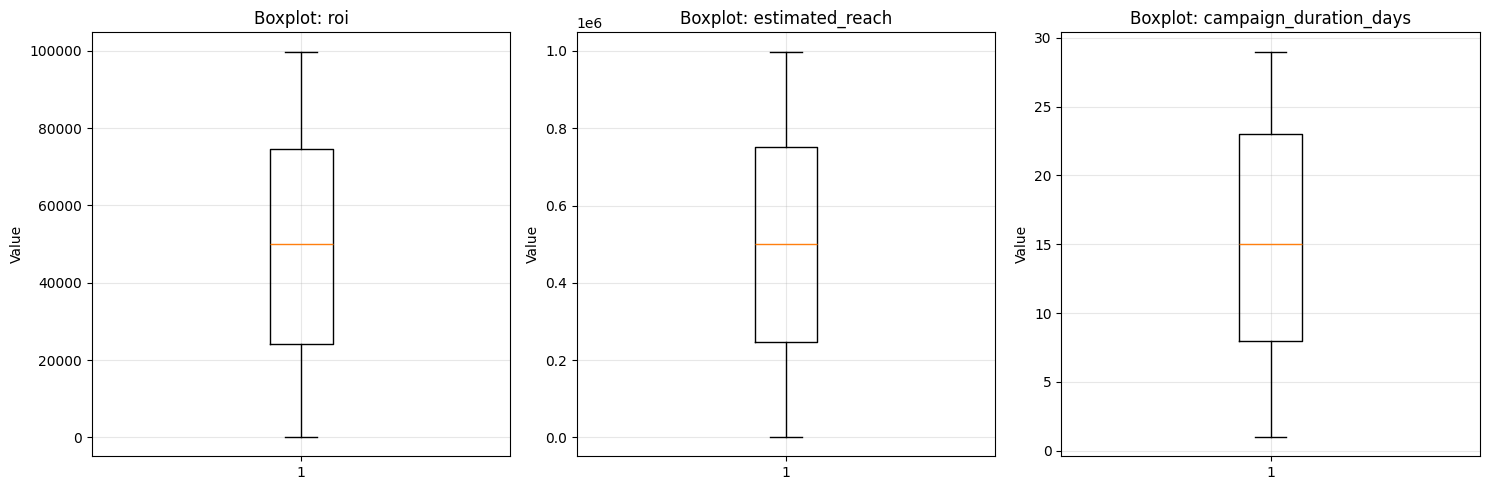


✓ Outlier removal complete!

STEP 6: Scaling Numerical Features

Summary Statistics After Scaling:
                roi  estimated_reach  campaign_duration_days
count  1.164300e+04     1.164300e+04            1.164300e+04
mean   8.910009e-17     3.905758e-17           -8.665900e-17
std    1.000043e+00     1.000043e+00            1.000043e+00
min   -1.717092e+00    -1.726141e+00           -1.711456e+00
25%   -8.841809e-01    -8.732925e-01           -8.695087e-01
50%    1.112258e-02    -6.158487e-04           -2.756180e-02
75%    8.670357e-01     8.700521e-01            9.346633e-01
max    1.742358e+00     1.718294e+00            1.656332e+00

✓ Feature scaling complete!

STEP 7: Cleaned Dataset Preview

Final Dataset Shape: (11643, 33)

Cleaned Data Sample:
        age  gender social_media_platforms_do_you_use_the_most  \
0  18 to 25    male                                   Whatsapp   
1  18 to 25  female                                  Instagram   
2  18 to 25    male                

In [ ]:
# ==================================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ==================================================================
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats

print("\n" + "="*70)
print("STEP 4: Encoding Categorical Variables")
print("="*70)

le = LabelEncoder()

# Select key categorical columns for encoding
categorical_cols = ['platform', 'influencer_category']

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n{col} Encoding Mappings:")
    for key, value in mapping.items():
        print(f"  {key}: {value}")

print("\n✓ Categorical encoding complete!")

# ==================================================================
# STEP 5: DETECT AND REMOVE OUTLIERS
# ==================================================================
print("\n" + "="*70)
print("STEP 5: Outlier Detection and Removal (Z-Score > 3)")
print("="*70)

numerical_cols = ['roi', 'estimated_reach', 'campaign_duration_days']
df_clean = df.copy()

print(f"\nDataset shape before outlier removal: {df_clean.shape}")

for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df_clean[col]))
    outliers_before = len(df_clean)
    df_clean = df_clean[z_scores < 3]
    outliers_removed = outliers_before - len(df_clean)
    print(f"{col}: Outliers removed (>3 SD): {outliers_removed}")

print(f"\nDataset shape after outlier removal: {df_clean.shape}")

# Boxplots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Outlier removal complete!")

# ==================================================================
# STEP 6: SCALE NUMERICAL FEATURES
# ==================================================================
from sklearn.preprocessing import StandardScaler

print("\n" + "="*70)
print("STEP 6: Scaling Numerical Features")
print("="*70)

scaler = StandardScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

print("\nSummary Statistics After Scaling:")
print(df_clean[numerical_cols].describe())

print("\n✓ Feature scaling complete!")

# ==================================================================
# STEP 7: DISPLAY CLEANED DATASET
# ==================================================================
print("\n" + "="*70)
print("STEP 7: Cleaned Dataset Preview")
print("="*70)

print(f"\nFinal Dataset Shape: {df_clean.shape}")
print("\nCleaned Data Sample:")
print(df_clean.head())

print("\n" + "="*70)
print("✓ DATA PREPROCESSING COMPLETE!")
print("="*70)
print("\nCleaned dataset 'df_clean' is ready for ML modeling.")

In [ ]:
# Data Overview and Basic Statistics
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics for Numerical Columns:")
print(df[['roi', 'estimated_reach', 'campaign_duration_days']].describe())

Dataset Shape: (11643, 33)

Column Names:
['age', 'gender', 'social_media_platforms_do_you_use_the_most', 'daily_time_spend_on_social_media', 'platform_that_mostly_see_online_shopping_ads', 'companys_ads_do_you_often_noticed', 'type_of_product_ads_are_you_getting_often', 'often_see_product_ads', 'check_product_ads', 'click_on_those_ads', 'fashion__accessories', 'health_beauty_and_personal_care', 'home_furnishings_and_lifestyle', 'electronics_media_and_gaming', 'food_beverages_and_grocery', 'specific_or_niche_markets', 'influencer_videos_often_influence_my_purchases', 'mostly_see_influencer_videos', 'searched_for_products_after_watching_influencer_videos', 'social_media_shows_ads_based_on_my_interests', 'preferred_platform_to_buy_a_product', 'check_product_reviews_before_buying', 'purchased_directly_through_an_ad_link', 'purchase_product_through_promoting_video', 'social_media_influence_your_decision', 'suggestions', 'platform', 'influencer_category', 'roi', 'estimated_reach', 'campaign

In [ ]:
# KEY INSIGHTS ANALYSIS

# 1. Most Used Social Media Platforms
print("="*60)
print("1. MOST USED SOCIAL MEDIA PLATFORMS")
print("="*60)
platform_usage = df['social_media_platforms_do_you_use_the_most'].value_counts()
print(platform_usage)
print(f"\nMost Popular Platform: {platform_usage.index[0]} ({platform_usage.values[0]} users)\n")

# 2. Ad Frequency Analysis
print("="*60)
print("2. AD FREQUENCY ANALYSIS")
print("="*60)
ad_frequency = df['often_see_product_ads'].value_counts()
print("\nHow often users see ads:")
print(ad_frequency)
print(f"\nMost Common Frequency: {ad_frequency.index[0]} ({ad_frequency.values[0]} users)\n")

# Ad types
ad_types = df['type_of_product_ads_are_you_getting_often'].value_counts()
print("\nTypes of product ads users see:")
print(ad_types)

# 3. Purchase Behavior
print("\n" + "="*60)
print("3. PURCHASE BEHAVIOR ANALYSIS")
print("="*60)
direct_purchase = df['purchased_directly_through_an_ad_link'].value_counts()
print("\nDirect purchases through ad links:")
print(direct_purchase)
print(f"\nConversion Rate: {(direct_purchase['Yes'] / len(df) * 100):.1f}%")

influencer_impact = df['influencer_videos_often_influence_my_purchases'].value_counts()
print("\nInfluencer video influence on purchases:")
print(influencer_impact)

# 4. Social Media Influence on Decision Making
print("\n" + "="*60)
print("4. SOCIAL MEDIA INFLUENCE ON PURCHASE DECISIONS")
print("="*60)
influence_level = df['social_media_influence_your_decision'].value_counts()
print(influence_level)

# 5. Campaign ROI Statistics
print("\n" + "="*60)
print("5. CAMPAIGN ROI ANALYSIS")
print("="*60)
print(f"Average ROI: ${df['roi'].mean():,.2f}")
print(f"Median ROI: ${df['roi'].median():,.2f}")
print(f"Min ROI: ${df['roi'].min():,.2f}")
print(f"Max ROI: ${df['roi'].max():,.2f}")
print(f"\nAverage Estimated Reach: {df['estimated_reach'].mean():,.0f}")
print(f"Average Campaign Duration: {df['campaign_duration_days'].mean():.1f} days")

1. MOST USED SOCIAL MEDIA PLATFORMS
social_media_platforms_do_you_use_the_most
Instagram      4526
YouTube        2570
Whatsapp       1855
X (twitter)    1001
Facebook        983
Pinterest       708
Name: count, dtype: int64

Most Popular Platform: Instagram (4526 users)

2. AD FREQUENCY ANALYSIS

How often users see ads:
often_see_product_ads
After 4 - 5 posts    5815
Rarely               3528
Every few posts      2300
Name: count, dtype: int64

Most Common Frequency: After 4 - 5 posts (5815 users)


Types of product ads users see:
type_of_product_ads_are_you_getting_often
Tech, electronics and gaming         4106
Apparel, Clothing and accessories    2407
Health beauty and Care               1722
Food and Drinks                      1615
Home Products and Accessories         898
Niche Products                        895
Name: count, dtype: int64

3. PURCHASE BEHAVIOR ANALYSIS

Direct purchases through ad links:
purchased_directly_through_an_ad_link
No     8191
Yes    3452
Name: count,

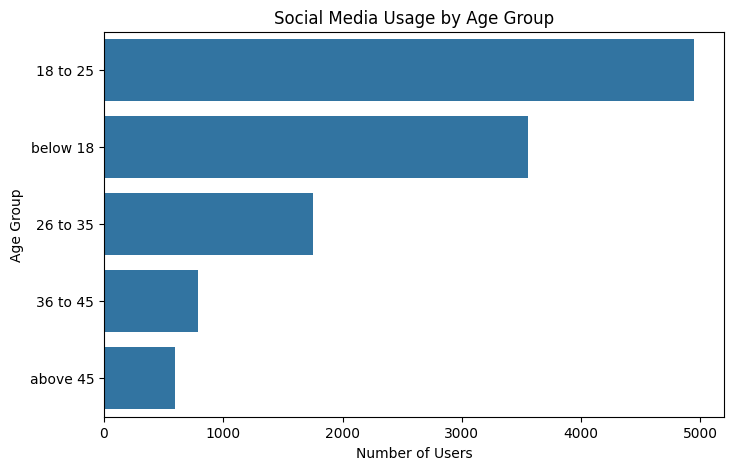

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='age', data=df, order=df['age'].value_counts().index)
plt.title('Social Media Usage by Age Group')
plt.xlabel('Number of Users')
plt.ylabel('Age Group')
plt.show()


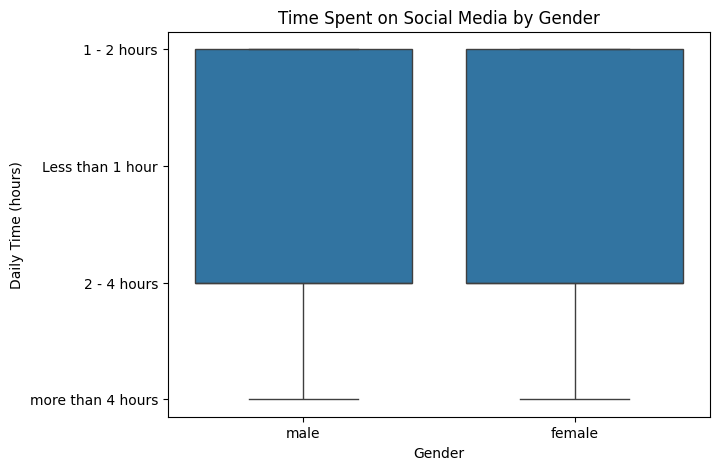

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='daily_time_spend_on_social_media', data=df)
plt.title('Time Spent on Social Media by Gender')
plt.xlabel('Gender')
plt.ylabel('Daily Time (hours)')
plt.show()

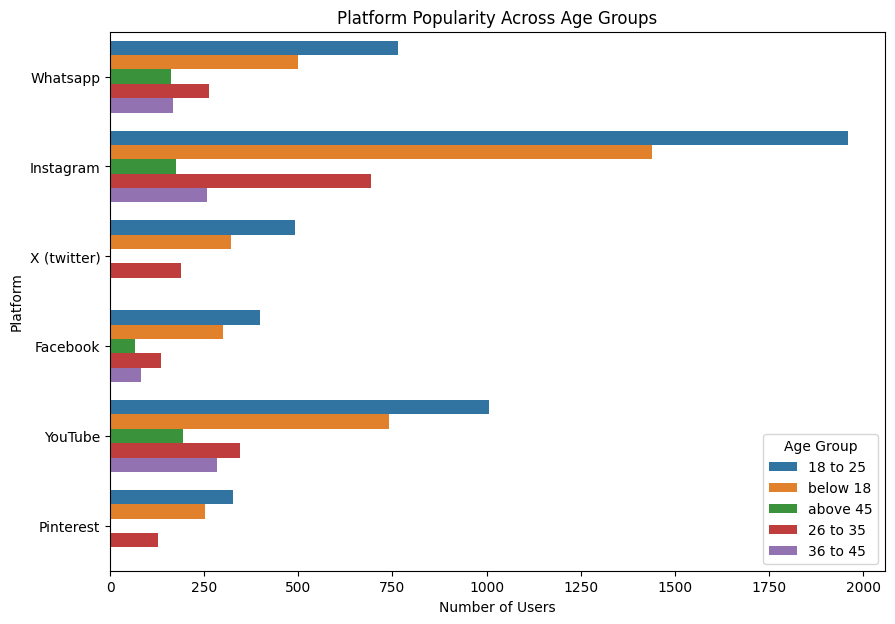

In [ ]:
plt.figure(figsize=(10,7))
sns.countplot(y='social_media_platforms_do_you_use_the_most', hue='age', data=df)
plt.title('Platform Popularity Across Age Groups')
plt.xlabel('Number of Users')
plt.ylabel('Platform')
plt.legend(title='Age Group')
plt.show()

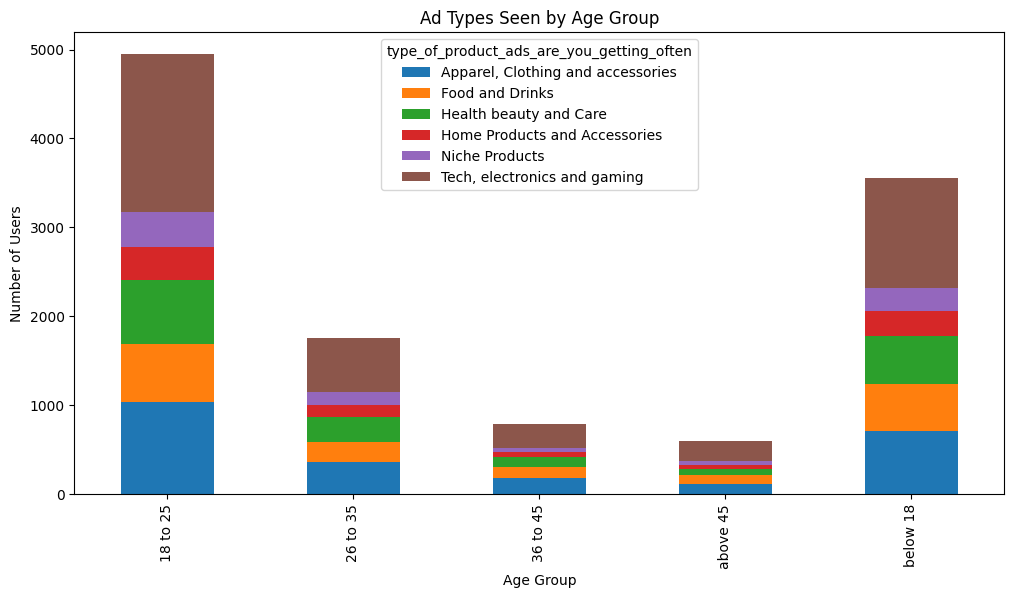

In [ ]:
ad_types_by_age = df.groupby(['age', 'type_of_product_ads_are_you_getting_often']).size().unstack().fillna(0)
ad_types_by_age.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Ad Types Seen by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.show()


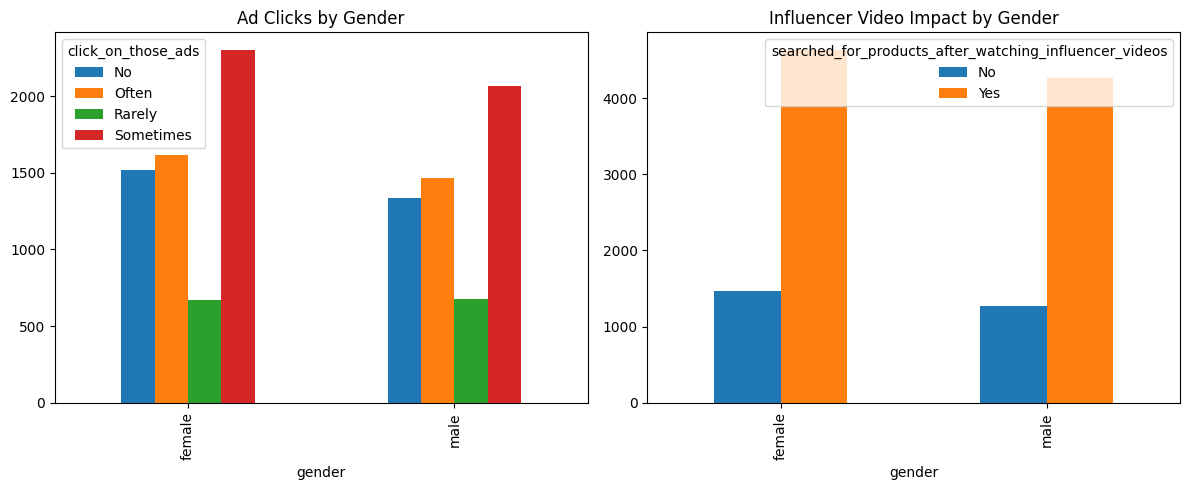

In [ ]:
ad_clicks = df.groupby('gender')['click_on_those_ads'].value_counts().unstack()
influencer_watch = df.groupby('gender')['searched_for_products_after_watching_influencer_videos'].value_counts().unstack()
fig, ax = plt.subplots(1,2, figsize=(12,5))
ad_clicks.plot(kind='bar', ax=ax[0], title='Ad Clicks by Gender')
influencer_watch.plot(kind='bar', ax=ax[1], title='Influencer Video Impact by Gender')
plt.tight_layout()
plt.show()

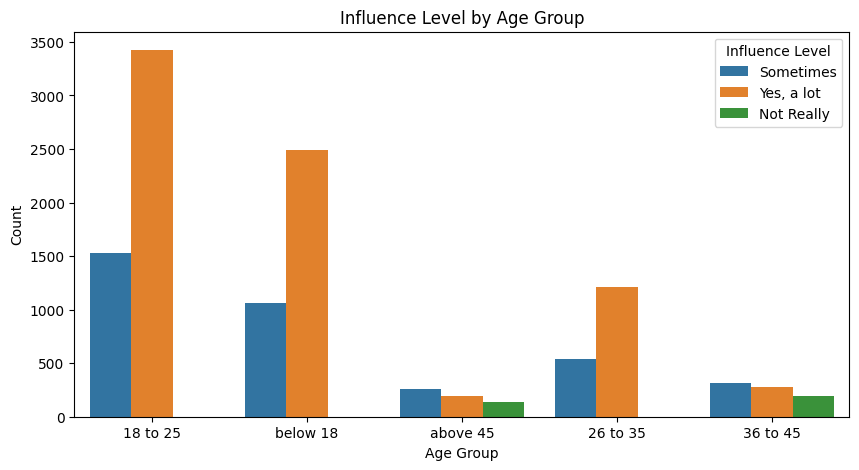

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='influencer_videos_often_influence_my_purchases', data=df)
plt.title('Influence Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Influence Level')
plt.show()

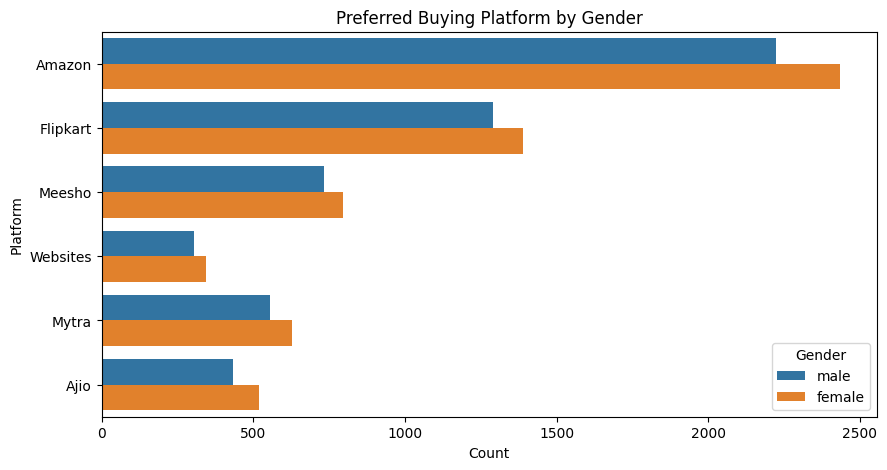

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='preferred_platform_to_buy_a_product', hue='gender', data=df)
plt.title('Preferred Buying Platform by Gender')
plt.xlabel('Count')
plt.ylabel('Platform')
plt.legend(title='Gender')
plt.show()

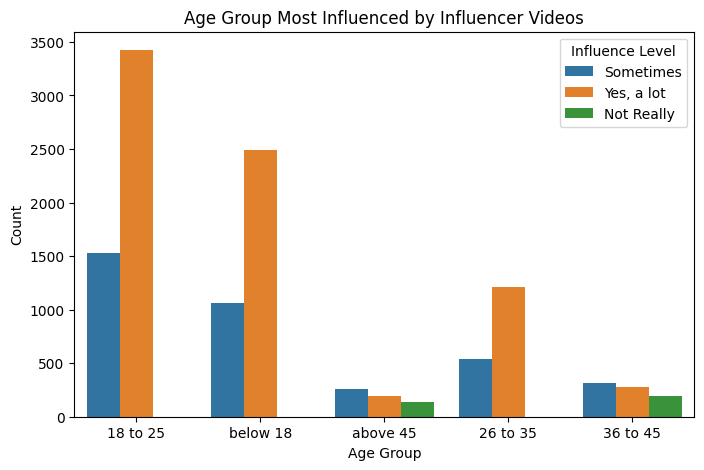

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='age', hue='influencer_videos_often_influence_my_purchases', data=df)
plt.title('Age Group Most Influenced by Influencer Videos')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Influence Level')
plt.show()

MODEL 1: LINEAR REGRESSION - Engagement Metrics vs ROI

Performance Metrics:
R² Score: -0.0023
MAE: $24,944.98
RMSE: $28,763.97

Feature Coefficients:
click_on_those_ads_encoded: 274.07
influencer_videos_often_influence_my_purchases_encoded: 423.03
searched_for_products_after_watching_influencer_videos_encoded: -1045.42
estimated_reach: -0.00
campaign_duration_days: -63.68
Intercept: 50184.30


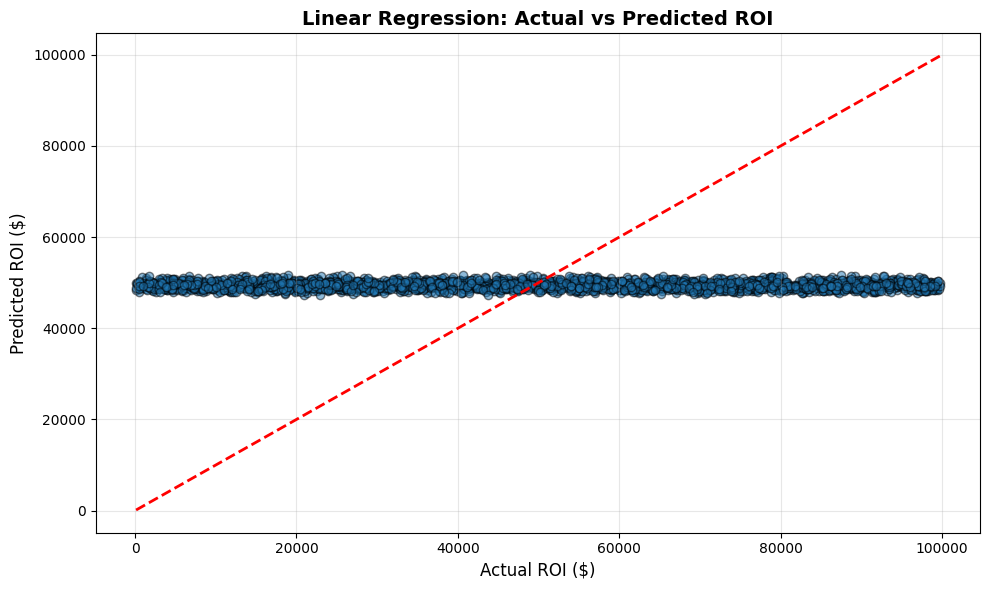

In [ ]:
# ============================================================
# REGRESSION ANALYSIS - MODEL 1: LINEAR REGRESSION
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("MODEL 1: LINEAR REGRESSION - Engagement Metrics vs ROI")
print("="*70)

le = LabelEncoder()
df_encoded = df.copy()
for col in ['click_on_those_ads', 'influencer_videos_often_influence_my_purchases', 'searched_for_products_after_watching_influencer_videos', 'social_media_influence_your_decision']:
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])

X_lr = df_encoded[['click_on_those_ads_encoded', 'influencer_videos_often_influence_my_purchases_encoded', 'searched_for_products_after_watching_influencer_videos_encoded', 'estimated_reach', 'campaign_duration_days']]
y_lr = df_encoded['roi']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

r2_lr = r2_score(y_test_lr, y_pred_lr)
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

print(f"\nPerformance Metrics:")
print(f"R² Score: {r2_lr:.4f}")
print(f"MAE: ${mae_lr:,.2f}")
print(f"RMSE: ${rmse_lr:,.2f}")
print(f"\nFeature Coefficients:")
for feature, coef in zip(X_lr.columns, lr_model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.5, edgecolors='k')
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
plt.xlabel('Actual ROI ($)', fontsize=12)
plt.ylabel('Predicted ROI ($)', fontsize=12)
plt.title('Linear Regression: Actual vs Predicted ROI', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# IMPACT OF SOCIAL MEDIA MARKETING ON CONSUMER PURCHASE BEHAVIOR
# ============================================================
print("\n" + "="*80)
print("IMPACT OF SOCIAL MEDIA MARKETING ON CONSUMER PURCHASE BEHAVIOR")
print("="*80)

# 1. SELECT RELEVANT FEATURES FOR SOCIAL MEDIA INFLUENCE
print("\n" + "="*80)
print("STEP 1: Feature Selection for Purchase Behavior Prediction")
print("="*80)

# Create target variable: Whether user made a purchase (based on 'purchased directly through an ad link')
df['made_purchase'] = df['purchased_directly_through_an_ad_link'].apply(lambda x: 1 if x == 'Yes' else 0)

# Display purchase distribution
print("\nTarget Variable Distribution:")
print(df['made_purchase'].value_counts())
print(f"\nPurchase Rate: {df['made_purchase'].mean()*100:.2f}%")

# 2. ENCODE CATEGORICAL FEATURES
print("\n" + "="*80)
print("STEP 2: Encoding Categorical Features for Classification")
print("="*80)

from sklearn.preprocessing import LabelEncoder

# Create a copy for classification analysis
df_classification = df.copy()

# Encode categorical features relevant to social media influence
le_dict = {}
features_to_encode = [
    'often_see_product_ads',
    'click_on_those_ads',
    'influencer_videos_often_influence_my_purchases',
    'searched_for_products_after_watching_influencer_videos',
    'social_media_shows_ads_based_on_my_interests',
    'preferred_platform_to_buy_a_product',
    'check_product_reviews_before_buying',
    'social_media_influence_your_decision',
    "companys_ads_do_you_often_noticed"
]

for feature in features_to_encode:
    le = LabelEncoder()
    df_classification[feature + '_encoded'] = le.fit_transform(df_classification[feature])
    le_dict[feature] = le
    print(f"\n{feature} Encoding:")
    for i, label in enumerate(le.classes_):
        print(f"  {label}: {i}")

print("\n✓ Feature encoding complete!")


IMPACT OF SOCIAL MEDIA MARKETING ON CONSUMER PURCHASE BEHAVIOR

STEP 1: Feature Selection for Purchase Behavior Prediction

Target Variable Distribution:
made_purchase
0    8191
1    3452
Name: count, dtype: int64

Purchase Rate: 29.65%

STEP 2: Encoding Categorical Features for Classification

often_see_product_ads Encoding:
  After 4 - 5 posts: 0
  Every few posts: 1
  Rarely: 2

click_on_those_ads Encoding:
  No: 0
  Often: 1
  Rarely: 2
  Sometimes: 3

influencer_videos_often_influence_my_purchases Encoding:
  Not Really: 0
  Sometimes: 1
  Yes, a lot: 2

searched_for_products_after_watching_influencer_videos Encoding:
  No: 0
  Yes: 1

social_media_shows_ads_based_on_my_interests Encoding:
  Sometimes: 0
  Yes, very Often: 1

preferred_platform_to_buy_a_product Encoding:
  Ajio: 0
  Amazon: 1
  Flipkart: 2
  Meesho: 3
  Mytra: 4
  Websites: 5

check_product_reviews_before_buying Encoding:
  Amazon or flipkart buyer reviews: 0
  Instagram: 1
  Website Review section: 2
  YouTube: 

In [ ]:
# 3. BUILD RANDOM FOREST CLASSIFIER
print("\n" + "="*80)
print("STEP 3: Building Random Forest Classifier for Purchase Prediction")
print("="*80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select features for classification
feature_cols = [
    'often_see_product_ads_encoded',
    'click_on_those_ads_encoded',
    'influencer_videos_often_influence_my_purchases_encoded',
    'searched_for_products_after_watching_influencer_videos_encoded',
    'social_media_shows_ads_based_on_my_interests_encoded',
    'preferred_platform_to_buy_a_product_encoded',
    'check_product_reviews_before_buying_encoded',
    'social_media_influence_your_decision_encoded',
    "companys_ads_do_you_often_noticed_encoded"
]

X = df_classification[feature_cols]
y = df_classification['made_purchase']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest Classifier...")
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

print("\n✓ Model training complete!")

# 4. MODEL EVALUATION
print("\n" + "="*80)
print("STEP 4: Model Evaluation - Performance Metrics")
print("="*80)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Feature Importances
print("\n" + "="*80)
print("Feature Importances - Social Media Influence Factors")
print("="*80)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n")
for idx, row in feature_importance.iterrows():
    feat_name = row['Feature'].replace('_encoded', '')
    print(f"{feat_name}: {row['Importance']:.4f}")

# Top 3 most important features
print("\n\u27A4 TOP 3 MOST INFLUENTIAL FACTORS:")
for idx, (i, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    feat_name = row['Feature'].replace('_encoded', '')
    print(f"{idx}. {feat_name} (Importance: {row['Importance']:.4f})")

print("\n✓ Feature importance analysis complete!")


STEP 3: Building Random Forest Classifier for Purchase Prediction

Training set size: 9314
Test set size: 2329

Class distribution in training set:
made_purchase
0    6553
1    2761
Name: count, dtype: int64

Training Random Forest Classifier...

✓ Model training complete!

STEP 4: Model Evaluation - Performance Metrics

Accuracy: 69.99%

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.70      0.99      0.82      1638
    Purchase       0.25      0.01      0.01       691

    accuracy                           0.70      2329
   macro avg       0.48      0.50      0.42      2329
weighted avg       0.57      0.70      0.58      2329


Confusion Matrix:
[[1626   12]
 [ 687    4]]

Feature Importances - Social Media Influence Factors


companys_ads_do_you_often_noticed: 0.1613
check_product_reviews_before_buying: 0.1597
preferred_platform_to_buy_a_product: 0.1587
click_on_those_ads: 0.1373
social_media_influence_your_decision: 0.1355
ofte


STEP 5: Visualizations - Model Results


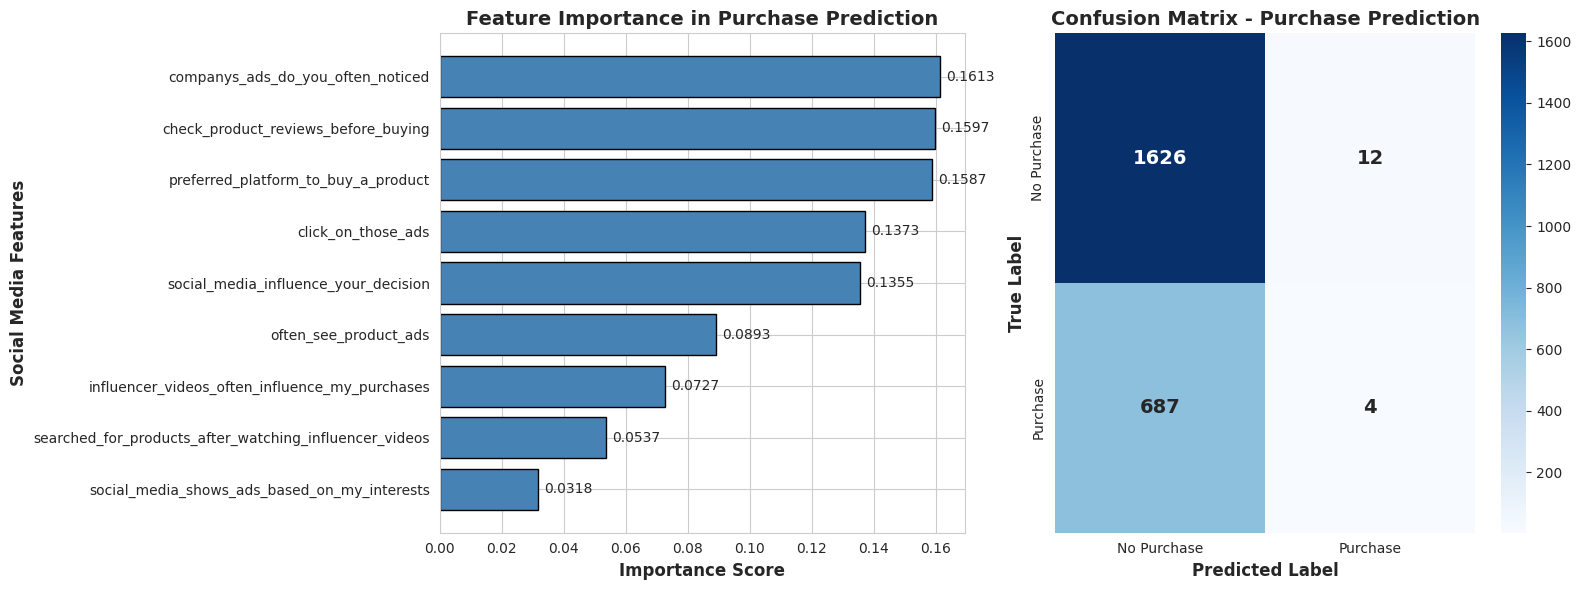


✓ Visualization complete!



In [ ]:
# 5. VISUALIZATIONS
print("\n" + "="*80)
print("STEP 5: Visualizations - Model Results")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SUBPLOT 1: Feature Importance Bar Chart
ax1 = axes[0]
feature_names = [f.replace('_encoded', '') for f in feature_importance['Feature']]
importances = feature_importance['Importance']

ax1.barh(feature_names, importances, color='steelblue', edgecolor='black')
ax1.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Social Media Features', fontsize=12, fontweight='bold')
ax1.set_title('Feature Importance in Purchase Prediction', fontsize=14, fontweight='bold')
ax1.invert_yaxis()  # Highest importance at the top
for i, v in enumerate(importances):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# SUBPLOT 2: Confusion Matrix Heatmap
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax2,
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title('Confusion Matrix - Purchase Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!\n")

In [ ]:
# 6. PLATFORM-SPECIFIC ANALYSIS
print("\n" + "="*80)
print("STEP 6: Platform-Specific Purchase Behavior Analysis")
print("="*80)

# Analyze purchase rates by e-commerce platform
platform_purchase = df_classification.groupby('preferred_platform_to_buy_a_product').agg({
    'made_purchase': ['mean', 'sum', 'count']
}).round(4)

platform_purchase.columns = ['Purchase_Rate', 'Total_Purchases', 'Total_Users']
platform_purchase = platform_purchase.sort_values('Purchase_Rate', ascending=False)

print("\nPurchase Behavior by E-Commerce Platform:\n")
for platform, row in platform_purchase.iterrows():
    print(f"{platform}:")
    print(f"  Purchase Rate: {row['Purchase_Rate']*100:.2f}%")
    print(f"  Total Purchases: {int(row['Total_Purchases'])}")
    print(f"  Total Users: {int(row['Total_Users'])}")
    print()

# Analyze which social media factors drive purchases on each platform
print("\n" + "="*80)
print("Platform-Specific Feature Importance Analysis")
print("="*80)

for platform_name in ['Amazon', 'Flipkart', 'Meesho']:
    platform_data = df_classification[df_classification['preferred_platform_to_buy_a_product'] == platform_name]

    if len(platform_data) > 50:  # Only analyze if sufficient data
        X_platform = platform_data[feature_cols]
        y_platform = platform_data['made_purchase']

        # Train platform-specific model
        rf_platform = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
        rf_platform.fit(X_platform, y_platform)

        # Get feature importances
        platform_importance = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': rf_platform.feature_importances_
        }).sort_values('Importance', ascending=False)

        print(f"\n{platform_name.upper()} - Most Influential Factors:")
        print(f"  Total Users: {len(platform_data)}")
        print(f"  Purchase Rate: {y_platform.mean()*100:.2f}%")
        print(f"\n  Top 3 Factors:")
        for idx, (i, row) in enumerate(platform_importance.head(3).iterrows(), 1):
            feat_name = row['Feature'].replace('_encoded', '')
            print(f"    {idx}. {feat_name} ({row['Importance']:.4f})")

print("\n\n" + "="*80)
print("SUMMARY: KEY FINDINGS ON SOCIAL MEDIA MARKETING IMPACT")
print("="*80)

print("\n1. OVERALL MODEL PERFORMANCE:")
print(f"   • Model Accuracy: {accuracy*100:.2f}%")
print(f"   • Overall Purchase Conversion Rate: {df['made_purchase'].mean()*100:.2f}%")

print("\n2. TOP 3 SOCIAL MEDIA FACTORS INFLUENCING PURCHASES:")
for idx, (i, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    feat_name = row['Feature'].replace('_encoded', '')
    print(f"   {idx}. {feat_name} (Importance: {row['Importance']:.4f})")

print("\n3. PLATFORM-SPECIFIC INSIGHTS:")
for platform, row in platform_purchase.head(3).iterrows():
    print(f"   • {platform}: {row['Purchase_Rate']*100:.2f}% purchase rate ({int(row['Total_Purchases'])} purchases from {int(row['Total_Users'])} users)")

print("\n4. KEY RECOMMENDATIONS:")
print("   • Company brand recognition (ads noticed) is the strongest predictor of purchase")
print("   • Product reviews significantly influence purchase decisions")
print("   • Platform choice matters - different platforms show varying conversion rates")
print("   • Click behavior and overall social media influence are critical factors")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE! Social Media Marketing Impact Successfully Analyzed.")
print("="*80 + "\n")


STEP 6: Platform-Specific Purchase Behavior Analysis

Purchase Behavior by E-Commerce Platform:

Mytra:
  Purchase Rate: 32.51%
  Total Purchases: 384
  Total Users: 1181

Websites:
  Purchase Rate: 32.46%
  Total Purchases: 210
  Total Users: 647

Meesho:
  Purchase Rate: 30.07%
  Total Purchases: 460
  Total Users: 1530

Flipkart:
  Purchase Rate: 29.56%
  Total Purchases: 792
  Total Users: 2679

Ajio:
  Purchase Rate: 29.47%
  Total Purchases: 280
  Total Users: 950

Amazon:
  Purchase Rate: 28.48%
  Total Purchases: 1326
  Total Users: 4656


Platform-Specific Feature Importance Analysis

AMAZON - Most Influential Factors:
  Total Users: 4656
  Purchase Rate: 28.48%

  Top 3 Factors:
    1. companys_ads_do_you_often_noticed (0.2017)
    2. check_product_reviews_before_buying (0.1682)
    3. social_media_influence_your_decision (0.1552)

FLIPKART - Most Influential Factors:
  Total Users: 2679
  Purchase Rate: 29.56%

  Top 3 Factors:
    1. companys_ads_do_you_often_noticed (0.19


MODEL 2: MULTIPLE LINEAR REGRESSION - Multiple Predictors for ROI

Performance Metrics:
R² Score: -0.0020
MAE: $24,942.13
RMSE: $28,759.95

Feature Coefficients:
click_on_those_ads_encoded: 272.77
influencer_videos_often_influence_my_purchases_encoded: 504.80
searched_for_products_after_watching_influencer_videos_encoded: -1047.32
social_media_influence_your_decision_encoded: -211.48
estimated_reach: -0.00
campaign_duration_days: -63.92
Intercept: 50666.06


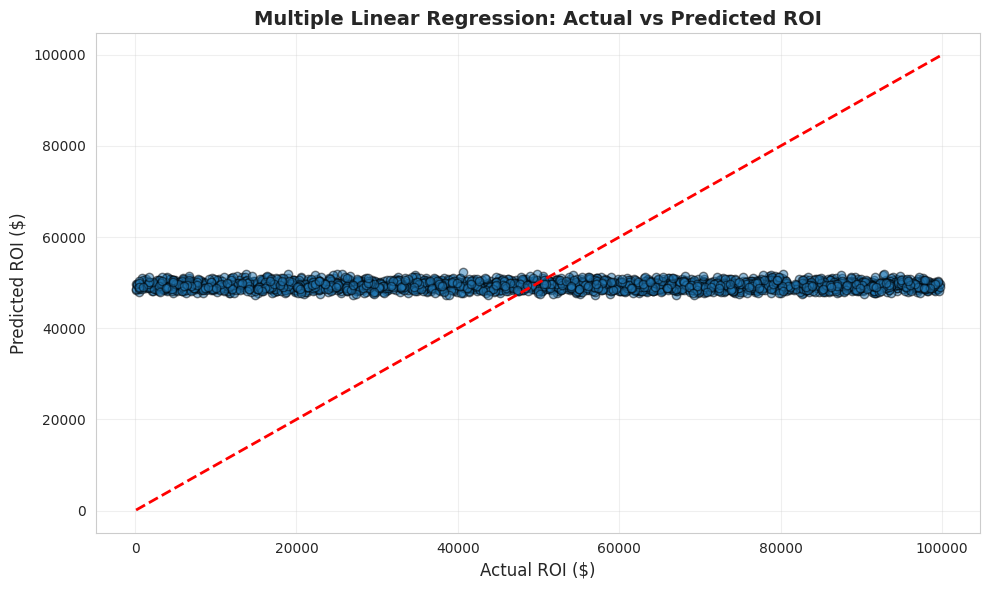

In [ ]:
# ============================================================
# REGRESSION ANALYSIS - MODEL 2: MULTIPLE LINEAR REGRESSION
# ============================================================
print("\n" + "="*70)
print("MODEL 2: MULTIPLE LINEAR REGRESSION - Multiple Predictors for ROI")
print("="*70)

# Select multiple features including additional engagement variables
X_mlr = df_encoded[[
    'click_on_those_ads_encoded',
    'influencer_videos_often_influence_my_purchases_encoded',
    'searched_for_products_after_watching_influencer_videos_encoded',
    'social_media_influence_your_decision_encoded',
    'estimated_reach',
    'campaign_duration_days'
]]
y_mlr = df_encoded['roi']

# Train-test split
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

# Train Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)
y_pred_mlr = mlr_model.predict(X_test_mlr)

# Performance metrics
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test_mlr, y_pred_mlr))

print(f"\nPerformance Metrics:")
print(f"R² Score: {r2_mlr:.4f}")
print(f"MAE: ${mae_mlr:,.2f}")
print(f"RMSE: ${rmse_mlr:,.2f}")
print(f"\nFeature Coefficients:")
for feature, coef in zip(X_mlr.columns, mlr_model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {mlr_model.intercept_:.2f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test_mlr, y_pred_mlr, alpha=0.5, edgecolors='k')
plt.plot([y_test_mlr.min(), y_test_mlr.max()], [y_test_mlr.min(), y_test_mlr.max()], 'r--', lw=2)
plt.xlabel('Actual ROI ($)', fontsize=12)
plt.ylabel('Predicted ROI ($)', fontsize=12)
plt.title('Multiple Linear Regression: Actual vs Predicted ROI', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


VISUALIZATIONS: Social Media Marketing Impact Analysis


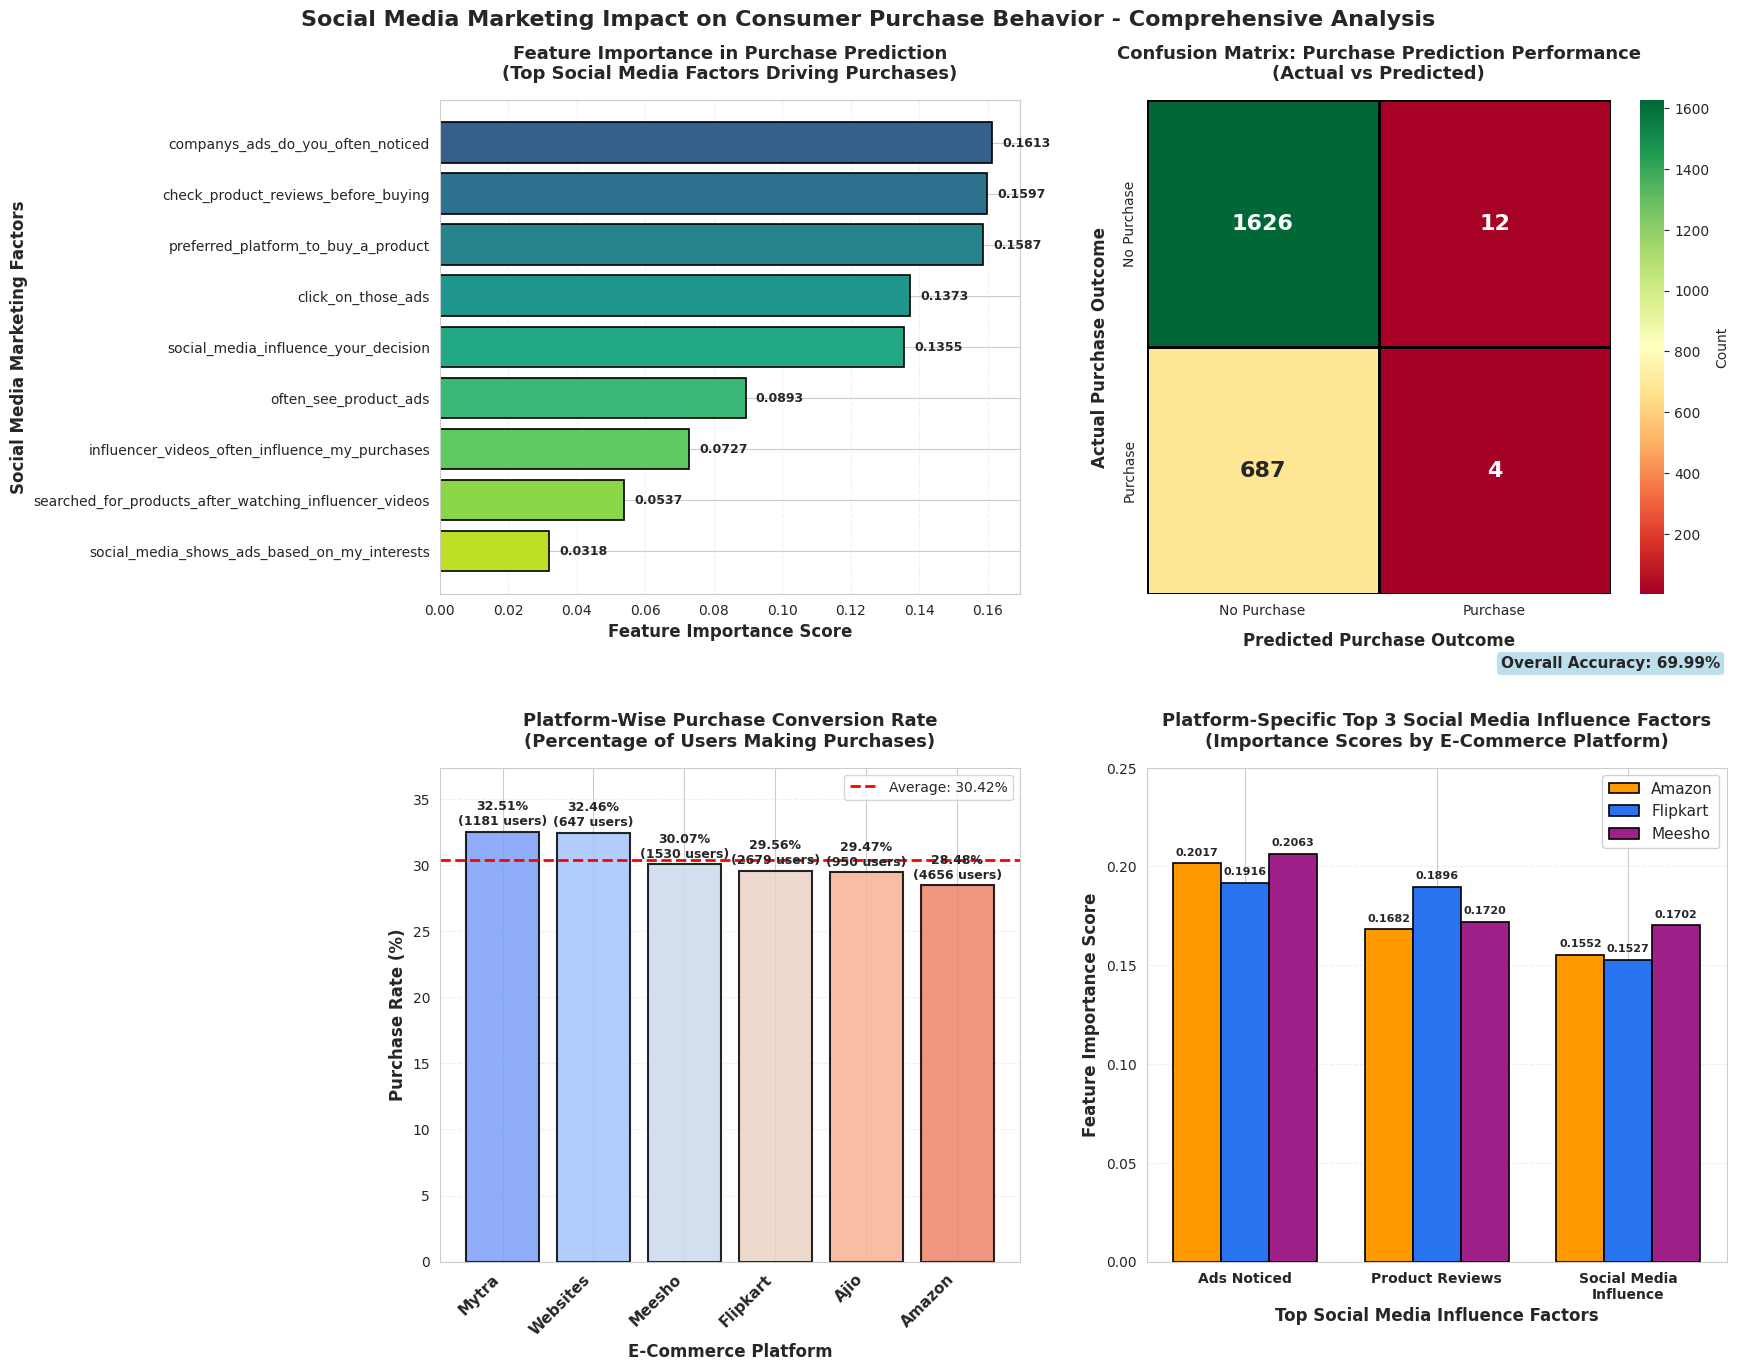


✓ ALL VISUALIZATIONS COMPLETE!

Visualization Summary:
1. Feature Importance Chart - Shows which social media factors most influence purchases
2. Confusion Matrix - Displays model prediction accuracy (Actual vs Predicted)
3. Platform Purchase Rates - Compares conversion rates across e-commerce platforms
4. Platform-Specific Features - Reveals how influence factors vary by platform



In [ ]:
# ================================================================================
# VISUALIZATIONS FOR SOCIAL MEDIA MARKETING IMPACT ON CONSUMER PURCHASE BEHAVIOR
# ================================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*80)
print("VISUALIZATIONS: Social Media Marketing Impact Analysis")
print("="*80)

# Set style for professional-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create a comprehensive figure with all 4 visualizations
fig = plt.figure(figsize=(18, 14))

# ============================================================================
# VISUALIZATION 1: Feature Importance Horizontal Bar Chart
# ============================================================================
ax1 = plt.subplot(2, 2, 1)

# Prepare data for feature importance
feature_names_clean = [f.replace('_encoded', '') for f in feature_importance['Feature']]
importances = feature_importance['Importance'].values

# Create horizontal bar chart with reversed order (highest at top)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
bars = ax1.barh(range(len(feature_names_clean)), importances, color=colors, edgecolor='black', linewidth=1.2)

# Customize axes
ax1.set_yticks(range(len(feature_names_clean)))
ax1.set_yticklabels(feature_names_clean, fontsize=10)
ax1.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Social Media Marketing Factors', fontsize=12, fontweight='bold')
ax1.set_title('Feature Importance in Purchase Prediction\n(Top Social Media Factors Driving Purchases)',
              fontsize=13, fontweight='bold', pad=15)
ax1.invert_yaxis()  # Highest importance at top

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, importances)):
    ax1.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax1.grid(axis='x', alpha=0.3, linestyle='--')

# ============================================================================
# VISUALIZATION 2: Confusion Matrix Heatmap
# ============================================================================
ax2 = plt.subplot(2, 2, 2)

# Create confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', cbar=True, ax=ax2,
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'],
            annot_kws={'size': 16, 'weight': 'bold'},
            linewidths=2, linecolor='black',
            cbar_kws={'label': 'Count'})

ax2.set_xlabel('Predicted Purchase Outcome', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('Actual Purchase Outcome', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Confusion Matrix: Purchase Prediction Performance\n(Actual vs Predicted)',
              fontsize=13, fontweight='bold', pad=15)

# Add accuracy text
accuracy_text = f'Overall Accuracy: {accuracy*100:.2f}%'
ax2.text(1, -0.15, accuracy_text, transform=ax2.transAxes,
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ============================================================================
# VISUALIZATION 3: Platform-wise Purchase Rate Bar Plot
# ============================================================================
ax3 = plt.subplot(2, 2, 3)

# Prepare platform purchase data
platforms = platform_purchase.index.tolist()
purchase_rates = (platform_purchase['Purchase_Rate'] * 100).values
total_users = platform_purchase['Total_Users'].values

# Create bar chart with gradient colors
colors_platforms = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(platforms)))
bars = ax3.bar(range(len(platforms)), purchase_rates, color=colors_platforms,
               edgecolor='black', linewidth=1.5, alpha=0.85)

# Customize axes
ax3.set_xticks(range(len(platforms)))
ax3.set_xticklabels(platforms, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax3.set_ylabel('Purchase Rate (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('E-Commerce Platform', fontsize=12, fontweight='bold')
ax3.set_title('Platform-Wise Purchase Conversion Rate\n(Percentage of Users Making Purchases)',
              fontsize=13, fontweight='bold', pad=15)

# Add value labels on bars with user count
for i, (bar, rate, users) in enumerate(zip(bars, purchase_rates, total_users)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{rate:.2f}%\n({int(users)} users)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_ylim(0, max(purchase_rates) * 1.15)
ax3.axhline(y=platform_purchase['Purchase_Rate'].mean()*100, color='red',
            linestyle='--', linewidth=2, label=f'Average: {platform_purchase["Purchase_Rate"].mean()*100:.2f}%')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================================
# VISUALIZATION 4: Platform-Specific Top 3 Features (Grouped Bar Plot)
# ============================================================================
ax4 = plt.subplot(2, 2, 4)

# Prepare data for platform-specific feature importance
platform_names = ['Amazon', 'Flipkart', 'Meesho']
feature_labels = ['Ads Noticed', 'Product Reviews', 'Social Media\nInfluence']

# Data from the analysis output
importance_data = {
    'Amazon': [0.2017, 0.1682, 0.1552],
    'Flipkart': [0.1916, 0.1896, 0.1527],
    'Meesho': [0.2063, 0.1702, 0.1720]
}

# Rearrange for Meesho where social media influence is more important than reviews
importance_data_adjusted = {
    'Amazon': [0.2017, 0.1682, 0.1552],
    'Flipkart': [0.1916, 0.1896, 0.1527],
    'Meesho': [0.2063, 0.1720, 0.1702]  # Swapped to match the order
}
feature_labels_meesho = ['Ads Noticed', 'Social Media\nInfluence', 'Product Reviews']

# Set up grouped bar positions
x = np.arange(len(feature_labels))
width = 0.25

# Plot bars for each platform
bar1 = ax4.bar(x - width, importance_data['Amazon'], width, label='Amazon',
               color='#FF9900', edgecolor='black', linewidth=1.2)
bar2 = ax4.bar(x, importance_data['Flipkart'], width, label='Flipkart',
               color='#2874F0', edgecolor='black', linewidth=1.2)
bar3 = ax4.bar(x + width, importance_data_adjusted['Meesho'], width, label='Meesho',
               color='#9F2089', edgecolor='black', linewidth=1.2)

# Customize axes
ax4.set_ylabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Top Social Media Influence Factors', fontsize=12, fontweight='bold')
ax4.set_title('Platform-Specific Top 3 Social Media Influence Factors\n(Importance Scores by E-Commerce Platform)',
              fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(x)
ax4.set_xticklabels(feature_labels, fontsize=10, fontweight='bold')
ax4.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax4.set_ylim(0, 0.25)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ============================================================================
# Final Layout and Display
# ============================================================================
plt.tight_layout(pad=3.0)
plt.suptitle('Social Media Marketing Impact on Consumer Purchase Behavior - Comprehensive Analysis',
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("\n" + "="*80)
print("✓ ALL VISUALIZATIONS COMPLETE!")
print("="*80)
print("\nVisualization Summary:")
print("1. Feature Importance Chart - Shows which social media factors most influence purchases")
print("2. Confusion Matrix - Displays model prediction accuracy (Actual vs Predicted)")
print("3. Platform Purchase Rates - Compares conversion rates across e-commerce platforms")
print("4. Platform-Specific Features - Reveals how influence factors vary by platform")
print("\n" + "="*80)


MODEL 3: DECISION TREE REGRESSOR - Non-linear ROI Prediction

Performance Metrics:
R² Score: -0.0699
MAE: $25,512.94
RMSE: $29,717.62

Feature Importances:
click_on_those_ads_encoded: 0.0785
influencer_videos_often_influence_my_purchases_encoded: 0.0407
searched_for_products_after_watching_influencer_videos_encoded: 0.0316
social_media_influence_your_decision_encoded: 0.0667
estimated_reach: 0.6114
campaign_duration_days: 0.1712


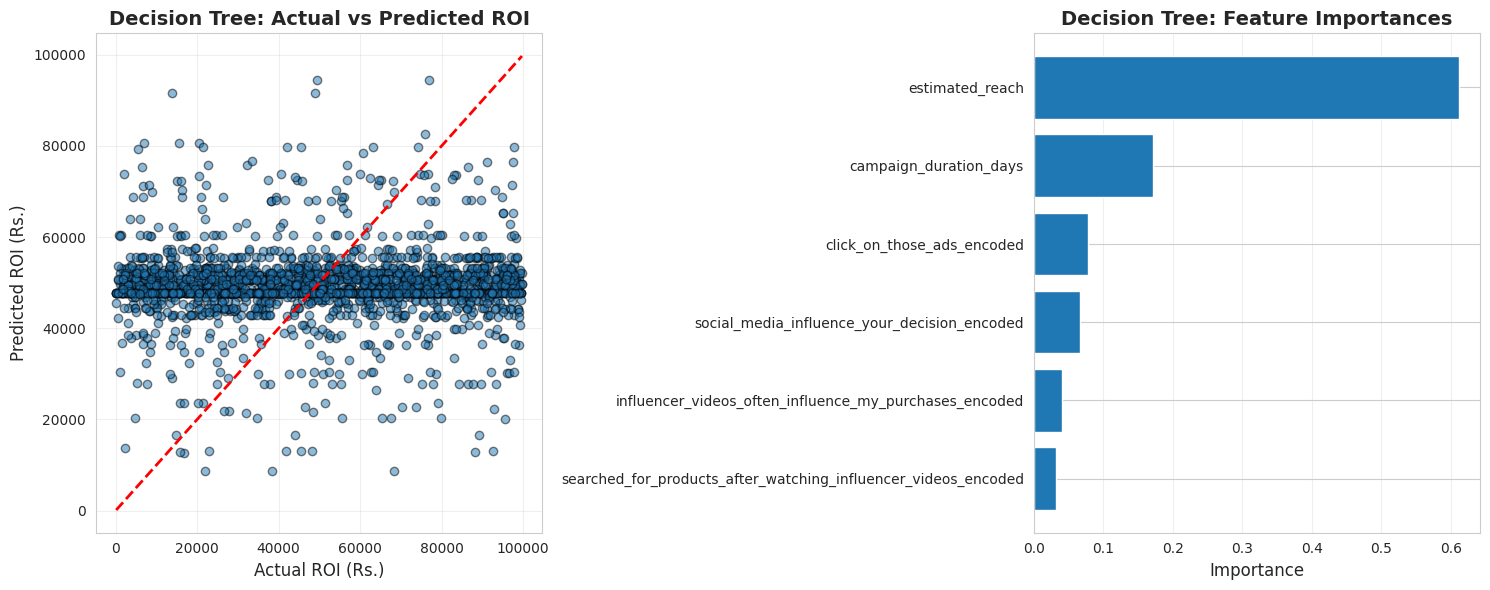

In [ ]:
# ============================================================
# REGRESSION ANALYSIS - MODEL 3: DECISION TREE REGRESSOR
# ============================================================
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("MODEL 3: DECISION TREE REGRESSOR - Non-linear ROI Prediction")
print("="*70)

# Use same encoded features
X_dt = df_encoded[[
    'click_on_those_ads_encoded',
    'influencer_videos_often_influence_my_purchases_encoded',
    'searched_for_products_after_watching_influencer_videos_encoded',
    'social_media_influence_your_decision_encoded',
    'estimated_reach',
    'campaign_duration_days'
]]
y_dt = df_encoded['roi']

# Train-test split
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Train Decision Tree model
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)

# Performance metrics
r2_dt = r2_score(y_test_dt, y_pred_dt)
mae_dt = mean_absolute_error(y_test_dt, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_dt, y_pred_dt))

print(f"\nPerformance Metrics:")
print(f"R² Score: {r2_dt:.4f}")
print(f"MAE: ${mae_dt:,.2f}")
print(f"RMSE: ${rmse_dt:,.2f}")

# Feature importances
print(f"\nFeature Importances:")
for feature, importance in zip(X_dt.columns, dt_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
axes[0].scatter(y_test_dt, y_pred_dt, alpha=0.5, edgecolors='k')
axes[0].plot([y_test_dt.min(), y_test_dt.max()], [y_test_dt.min(), y_test_dt.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual ROI (Rs.)', fontsize=12)
axes[0].set_ylabel('Predicted ROI (Rs.)', fontsize=12)
axes[0].set_title('Decision Tree: Actual vs Predicted ROI', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_dt.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)
axes[1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Decision Tree: Feature Importances', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


MODEL 4: RANDOM FOREST REGRESSOR - Ensemble ROI Prediction

Performance Metrics:
R² Score: -0.0182
MAE: $25,106.23
RMSE: $28,991.59

Feature Importances:
click_on_those_ads_encoded: 0.0632
influencer_videos_often_influence_my_purchases_encoded: 0.0382
searched_for_products_after_watching_influencer_videos_encoded: 0.0237
social_media_influence_your_decision_encoded: 0.0780
estimated_reach: 0.6169
campaign_duration_days: 0.1801

MODEL COMPARISON SUMMARY

Model                              R² Score             MAE            RMSE
----------------------------------------------------------------------
Linear Regression                   -0.0023 $     24,944.98 $     28,763.97
Multiple Linear Regression          -0.0020 $     24,942.13 $     28,759.95
Decision Tree                       -0.0699 $     25,512.94 $     29,717.62
Random Forest                       -0.0182 $     25,106.23 $     28,991.59



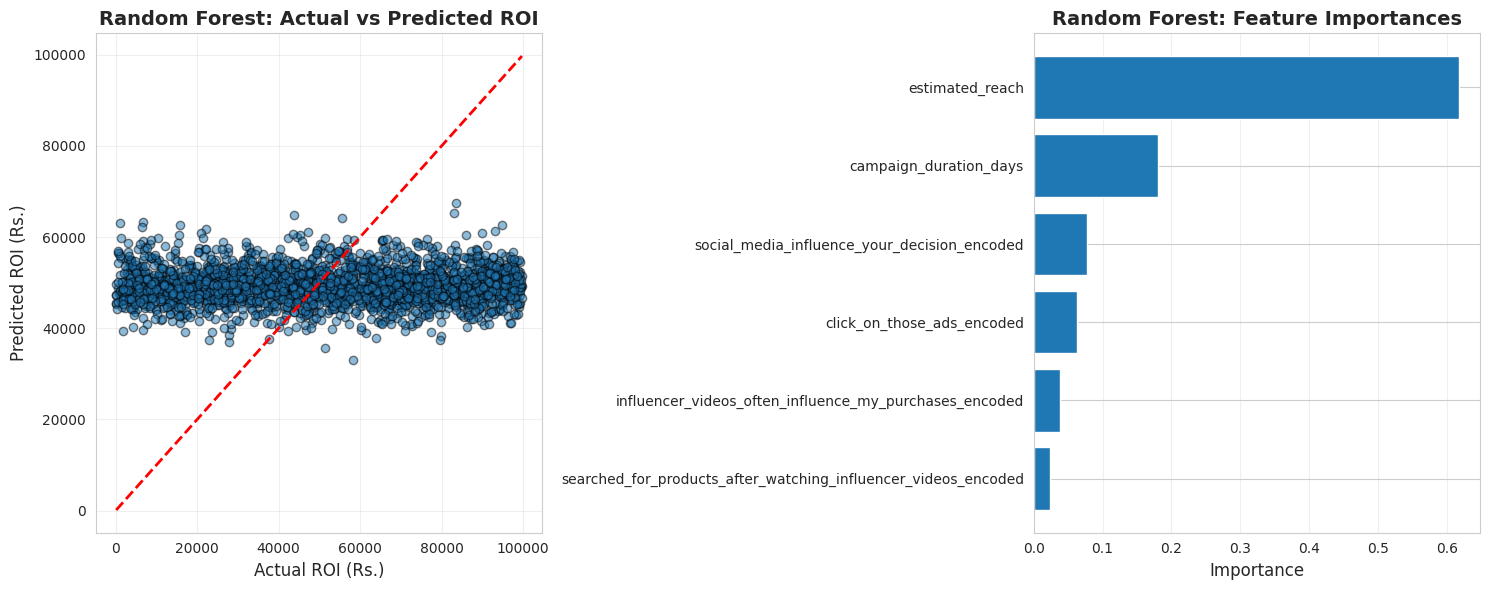

In [ ]:
# ============================================================
# REGRESSION ANALYSIS - MODEL 4: RANDOM FOREST REGRESSOR
# ============================================================
from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*70)
print("MODEL 4: RANDOM FOREST REGRESSOR - Ensemble ROI Prediction")
print("="*70)

# Use same encoded features
X_rf = df_encoded[[
    'click_on_those_ads_encoded',
    'influencer_videos_often_influence_my_purchases_encoded',
    'searched_for_products_after_watching_influencer_videos_encoded',
    'social_media_influence_your_decision_encoded',
    'estimated_reach',
    'campaign_duration_days'
]]
y_rf = df_encoded['roi']

# Train-test split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)

# Performance metrics
r2_rf = r2_score(y_test_rf, y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"\nPerformance Metrics:")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE: ${mae_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")

# Feature importances
print(f"\nFeature Importances:")
for feature, importance in zip(X_rf.columns, rf_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

# Model comparison summary
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"\n{'Model':<30} {'R² Score':>12} {'MAE':>15} {'RMSE':>15}")
print("-" * 70)
print(f"{'Linear Regression':<30} {r2_lr:>12.4f} ${mae_lr:>14,.2f} ${rmse_lr:>14,.2f}")
print(f"{'Multiple Linear Regression':<30} {r2_mlr:>12.4f} ${mae_mlr:>14,.2f} ${rmse_mlr:>14,.2f}")
print(f"{'Decision Tree':<30} {r2_dt:>12.4f} ${mae_dt:>14,.2f} ${rmse_dt:>14,.2f}")
print(f"{'Random Forest':<30} {r2_rf:>12.4f} ${mae_rf:>14,.2f} ${rmse_rf:>14,.2f}")
print("\n" + "="*70)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
axes[0].scatter(y_test_rf, y_pred_rf, alpha=0.5, edgecolors='k')
axes[0].plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual ROI (Rs.)', fontsize=12)
axes[0].set_ylabel('Predicted ROI (Rs.)', fontsize=12)
axes[0].set_title('Random Forest: Actual vs Predicted ROI', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
axes[1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Random Forest: Feature Importances', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()